1. Import libraries

In [25]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

2. Defining dataset path

In [26]:
DATA_PATH = Path("../data/tanzania-agri-prices-data/data/processed/prices.csv")

MODEL_PATH = Path("../models/price_model.joblib")

print(DATA_PATH.resolve())
print(MODEL_PATH.resolve())

/home/salmah/Documents/agri-market-ai/backend/ml/data/tanzania-agri-prices-data/data/processed/prices.csv
/home/salmah/Documents/agri-market-ai/backend/ml/models/price_model.joblib


3. Loading the dataset

In [27]:
df = pd.read_csv(DATA_PATH)

df.head(10)

,week_start,week_end,region,crop,price
0,2024-12-02,2024-12-06,Dar es Salaam,maize,1000.0
1,2024-12-02,2024-12-06,Dar es Salaam,rice,2200.0
2,2024-12-02,2024-12-06,Dar es Salaam,beans,3100.0
3,2024-12-02,2024-12-06,Dar es Salaam,sorghum,NaN
4,2024-12-02,2024-12-06,Dar es Salaam,bulrush_millet,NaN
5,2024-12-02,2024-12-06,Dar es Salaam,finger_millet,NaN
6,2024-12-02,2024-12-06,Dar es Salaam,round_potato,NaN
7,2024-12-02,2024-12-06,Geita,maize,800.0
8,2024-12-02,2024-12-06,Geita,rice,1600.0
9,2024-12-02,2024-12-06,Geita,beans,3300.0


4. Inspecting the dataset

In [28]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nCrops:")
print(sorted(df["crop"].dropna().unique()))

print("\nRegions:")
print(sorted(df["region"].dropna().unique()))

print("\nPrice summary:")
print(df["price"].describe())

Shape: (11865, 5)

Columns:
['week_start', 'week_end', 'region', 'crop', 'price']

Missing values:
week_start       0
week_end         0
region           0
crop             0
price         2387
dtype: int64

Crops:
['beans', 'bulrush_millet', 'finger_millet', 'maize', 'rice', 'round_potato', 'sorghum']

Regions:
['Arusha', 'Dar es Salaam', 'Dodoma', 'Geita', 'Iringa', 'Kagera', 'Katavi', 'Kigoma', 'Kilimanjaro', 'Lindi', 'Manyara', 'Mara', 'Mbeya', 'Morogoro', 'Mtwara', 'Mwanza', 'National Average', 'Njombe', 'Pwani', 'Rukwa', 'Ruvuma', 'Shinyanga', 'Simiyu', 'Singida', 'Songwe', 'Tabora', 'Tanga']

Price summary:
count    9478.000000
mean     1751.151614
std       766.924679
min       400.000000
25%      1000.000000
50%      1800.000000
75%      2400.000000
max      4000.000000
Name: price, dtype: float64


5.converting dates

In [29]:
df["week_start"] = pd.to_datetime(df["week_start"])
df["week_end"] = pd.to_datetime(df["week_end"])

df.dtypes

week_start    datetime64[us]
week_end      datetime64[us]
region                   str
crop                     str
price                float64
dtype: object

6. Clean the dataset

In [30]:
df_clean = df.dropna(subset=["price"]).copy()

df_clean = df_clean[
    df_clean["region"] != "National Average"
].copy()

df_clean = df_clean.sort_values(
    ["crop", "region", "week_start"]
).reset_index(drop=True)

CLEANED_PATH = Path("../data/processed/prices_cleaned.csv")

df_clean.to_csv(
    CLEANED_PATH,
    index=False
)

print(
    "Cleaned data saved to:",
    CLEANED_PATH.resolve()
)

print("Rows after cleaning:", len(df_clean))

df_clean.head()

Cleaned data saved to: /home/salmah/Documents/agri-market-ai/backend/ml/data/processed/prices_cleaned.csv
Rows after cleaning: 8953


,week_start,week_end,region,crop,price
0,2024-12-09,2024-12-13,Arusha,beans,2600.0
1,2024-12-16,2024-12-20,Arusha,beans,2700.0
2,2024-12-23,2024-12-27,Arusha,beans,2700.0
3,2024-12-30,2025-01-03,Arusha,beans,2700.0
4,2025-01-06,2025-01-10,Arusha,beans,2700.0


In [31]:
raw_data = pd.read_csv("../data/raw/prices_raw.csv")
raw_data.head(20)

,week_start,week_end,region,crop,price
0,2024-12-02,2024-12-06,Dar es Salaam,maize,1000.0
1,2024-12-02,2024-12-06,Dar es Salaam,rice,2200.0
2,2024-12-02,2024-12-06,Dar es Salaam,beans,3100.0
3,2024-12-02,2024-12-06,Dar es Salaam,sorghum,NaN
4,2024-12-02,2024-12-06,Dar es Salaam,bulrush_millet,NaN
5,2024-12-02,2024-12-06,Dar es Salaam,finger_millet,NaN
6,2024-12-02,2024-12-06,Dar es Salaam,round_potato,NaN
7,2024-12-02,2024-12-06,Geita,maize,800.0
8,2024-12-02,2024-12-06,Geita,rice,1600.0
9,2024-12-02,2024-12-06,Geita,beans,3300.0


In [32]:
cleaned_data = pd.read_csv(
    "../data/processed/prices_cleaned.csv"
)
cleaned_data.head(20)

,week_start,week_end,region,crop,price
0,2024-12-09,2024-12-13,Arusha,beans,2600.0
1,2024-12-16,2024-12-20,Arusha,beans,2700.0
2,2024-12-23,2024-12-27,Arusha,beans,2700.0
3,2024-12-30,2025-01-03,Arusha,beans,2700.0
4,2025-01-06,2025-01-10,Arusha,beans,2700.0
5,2025-01-13,2025-01-17,Arusha,beans,2800.0
6,2025-01-20,2025-01-24,Arusha,beans,2700.0
7,2025-01-27,2025-01-31,Arusha,beans,2800.0
8,2025-02-03,2025-02-07,Arusha,beans,2700.0
9,2025-02-10,2025-02-14,Arusha,beans,2700.0


In [33]:
# Work from cleaned observed prices
weekly_df = df_clean[
    ["week_start", "region", "crop", "price"]
].copy()

weekly_df = weekly_df.sort_values(
    ["crop", "region", "week_start"]
)

weekly_df.head()

,week_start,region,crop,price
0,2024-12-09,Arusha,beans,2600.0
1,2024-12-16,Arusha,beans,2700.0
2,2024-12-23,Arusha,beans,2700.0
3,2024-12-30,Arusha,beans,2700.0
4,2025-01-06,Arusha,beans,2700.0


In [34]:
all_weeks = pd.date_range(
    start=weekly_df["week_start"].min(),
    end=weekly_df["week_start"].max(),
    freq="7D"
)

crops = weekly_df["crop"].unique()
regions = weekly_df["region"].unique()

full_index = pd.MultiIndex.from_product(
    [
        crops,
        regions,
        all_weeks,
    ],
    names=[
        "crop",
        "region",
        "week_start",
    ],
)

full_weekly_df = (
    weekly_df
    .set_index(
        ["crop", "region", "week_start"]
    )
    .reindex(full_index)
    .reset_index()
)

print("Original cleaned rows:", len(weekly_df))
print("Full weekly grid rows:", len(full_weekly_df))

full_weekly_df.head()

Original cleaned rows: 8953
Full weekly grid rows: 14924


,crop,region,week_start,price
0,beans,Arusha,2024-12-02,NaN
1,beans,Arusha,2024-12-09,2600.0
2,beans,Arusha,2024-12-16,2700.0
3,beans,Arusha,2024-12-23,2700.0
4,beans,Arusha,2024-12-30,2700.0


7. Create lag features

In [35]:
grouped = full_weekly_df.groupby(
    ["crop", "region"]
)["price"]

full_weekly_df["price_lag_1"] = grouped.shift(1)
full_weekly_df["price_lag_2"] = grouped.shift(2)
full_weekly_df["price_lag_3"] = grouped.shift(3)
full_weekly_df["price_lag_4"] = grouped.shift(4)

In [36]:
full_weekly_df["change_1w"] = (
    full_weekly_df["price_lag_1"]
    - full_weekly_df["price_lag_2"]
)

full_weekly_df["change_2w"] = (
    full_weekly_df["price_lag_2"]
    - full_weekly_df["price_lag_3"]
)

full_weekly_df["pct_change_1w"] = (
    (
        full_weekly_df["price_lag_1"]
        - full_weekly_df["price_lag_2"]
    )
    / full_weekly_df["price_lag_2"]
) * 100

In [37]:
full_weekly_df["month"] = (
    full_weekly_df["week_start"].dt.month
)

full_weekly_df["week_of_year"] = (
    full_weekly_df["week_start"]
    .dt.isocalendar()
    .week
    .astype(int)
)

full_weekly_df["year"] = (
    full_weekly_df["week_start"].dt.year
)

In [38]:
grouped = full_weekly_df.groupby(
    ["crop", "region"]
)["price"]

full_weekly_df["price_lag_1"] = grouped.shift(1)
full_weekly_df["price_lag_2"] = grouped.shift(2)
full_weekly_df["price_lag_3"] = grouped.shift(3)
full_weekly_df["price_lag_4"] = grouped.shift(4)

8. Create rolling features

In [39]:
full_weekly_df["rolling_mean_4"] = grouped.transform(
    lambda s: s.shift(1).rolling(4).mean()
)

full_weekly_df["rolling_std_4"] = grouped.transform(
    lambda s: s.shift(1).rolling(4).std()
)

9. Add time features

In [40]:
full_weekly_df["month"] = (
    full_weekly_df["week_start"].dt.month
)

full_weekly_df["week_of_year"] = (
    full_weekly_df["week_start"]
    .dt.isocalendar()
    .week
    .astype(int)
)

full_weekly_df["year"] = (
    full_weekly_df["week_start"].dt.year
)

10. Create target

In [41]:
full_weekly_df["target_price"] = grouped.shift(-1)

In [42]:
required_columns = [
    "price_lag_1",
    "price_lag_2",
    "price_lag_3",
    "price_lag_4",
    "rolling_mean_4",
    "rolling_std_4",
    "change_1w",
    "change_2w",
    "pct_change_1w",
    "target_price",
]

true_weekly_model_df = (
    full_weekly_df
    .dropna(subset=required_columns)
    .copy()
)

print(
    "Rows available for true weekly modelling:",
    len(true_weekly_model_df)
)

Rows available for true weekly modelling: 3677


In [43]:
TRUE_WEEKLY_PATH = Path(
    "../data/processed/true_weekly_model_dataset.csv"
)

true_weekly_model_df.to_csv(
    TRUE_WEEKLY_PATH,
    index=False
)

print(
    "Saved to:",
    TRUE_WEEKLY_PATH.resolve()
)

Saved to: /home/salmah/Documents/agri-market-ai/backend/ml/data/processed/true_weekly_model_dataset.csv


In [23]:
MODEL_DATASET_PATH = Path(
    "../data/processed/model_dataset.csv"
)

full_weekly_df.to_csv(MODEL_DATASET_PATH, index=False)

11. Inspecting one crop/region

In [45]:
sample = full_weekly_df[
    (full_weekly_df["crop"] == "maize")
    & (full_weekly_df["region"] == "Arusha")
][
    [
        "week_start",
        "price",
        "price_lag_1",
        "price_lag_2",
        "target_price",
    ]
]

sample.head(15)

,week_start,price,price_lag_1,price_lag_2,target_price
6396,2024-12-02,NaN,NaN,NaN,700.0
6397,2024-12-09,700.0,NaN,NaN,600.0
6398,2024-12-16,600.0,700.0,NaN,600.0
6399,2024-12-23,600.0,600.0,700.0,600.0
6400,2024-12-30,600.0,600.0,600.0,700.0
6401,2025-01-06,700.0,600.0,600.0,700.0
6402,2025-01-13,700.0,700.0,600.0,800.0
6403,2025-01-20,800.0,700.0,700.0,700.0
6404,2025-01-27,700.0,800.0,700.0,700.0
6405,2025-02-03,700.0,700.0,800.0,700.0


12. Plot one market series

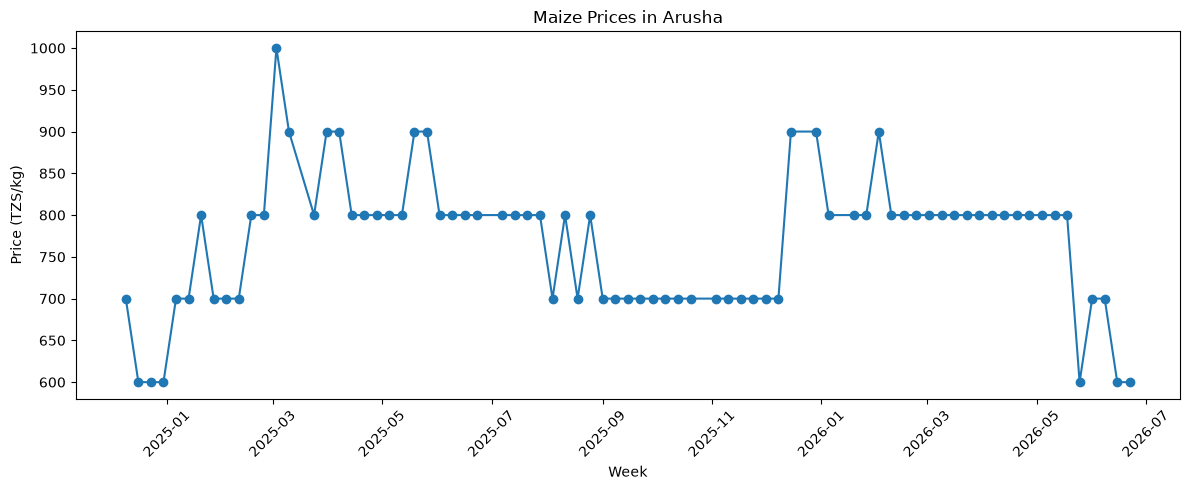

In [46]:
sample_plot = df_clean[
    (df_clean["crop"] == "maize")
    & (df_clean["region"] == "Arusha")
].copy()

plt.figure(figsize=(12, 5))

plt.plot(
    sample_plot["week_start"],
    sample_plot["price"],
    marker="o"
)

plt.title("Maize Prices in Arusha")
plt.xlabel("Week")
plt.ylabel("Price (TZS/kg)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

13. Chronological train/ test split

In [47]:
unique_dates = np.sort(
    true_weekly_model_df[
        "week_start"
    ].unique()
)

split_index = int(
    len(unique_dates) * 0.80
)

split_date = unique_dates[
    split_index
]

train_df = true_weekly_model_df[
    true_weekly_model_df[
        "week_start"
    ] < split_date
].copy()

test_df = true_weekly_model_df[
    true_weekly_model_df[
        "week_start"
    ] >= split_date
].copy()

print(
    "Split date:",
    pd.Timestamp(split_date).date()
)

print(
    "Training rows:",
    len(train_df)
)

print(
    "Testing rows:",
    len(test_df)
)

Split date: 2026-04-06
Training rows: 2715
Testing rows: 962


14. Define features

In [48]:
categorical_features = [
    "crop",
    "region",
]

numeric_features = [
    "price_lag_1",
    "price_lag_2",
    "price_lag_3",
    "price_lag_4",
    "rolling_mean_4",
    "rolling_std_4",
    "change_1w",
    "change_2w",
    "pct_change_1w",
    "month",
    "week_of_year",
    "year",
]

features = categorical_features + numeric_features

X_train = train_df[features].copy()
y_train = train_df["target_price"].copy()

X_test = test_df[features].copy()
y_test = test_df["target_price"].copy()

print(X_train.columns.tolist())
print(X_train.shape)
print(X_test.shape)

['crop', 'region', 'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_4', 'rolling_mean_4', 'rolling_std_4', 'change_1w', 'change_2w', 'pct_change_1w', 'month', 'week_of_year', 'year']
(2715, 14)
(962, 14)


15. Build preprocessing

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features,
        ),
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)

16. Build Random Forest

In [50]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ]
)

17. Train model

In [51]:
pipeline.fit(
    X_train,
    y_train
)

print("Model training complete.")

Model training complete.


18. Predict

In [52]:
predictions = pipeline.predict(
    X_test
)

predictions[:10]

array([2121.80555952, 2174.55039998, 1979.14901306, 1950.51645916,
       1951.7316064 , 1950.99827307, 1950.88716196, 1962.77326556,
       1987.26860105, 1892.37916498])

19. Evaluation function

In [53]:
def calculate_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return np.mean(
        np.abs(
            (y_true - y_pred)
            / y_true
        )
    ) * 100

20. Random Forest performance

In [54]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

mape = calculate_mape(
    y_test,
    predictions
)

print("RANDOM FOREST PERFORMANCE")
print("-------------------------")
print(f"MAE : TZS {mae:.2f}")
print(f"RMSE: TZS {rmse:.2f}")
print(f"R²  : {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

RANDOM FOREST PERFORMANCE
-------------------------
MAE : TZS 106.16
RMSE: TZS 165.84
R²  : 0.9450
MAPE: 7.21%


Baseline comparison

In [55]:
baseline_predictions = X_test[
    "price_lag_1"
].values

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

baseline_mape = calculate_mape(
    y_test,
    baseline_predictions
)

print("NAIVE BASELINE PERFORMANCE")
print("--------------------------")
print(f"MAE : TZS {baseline_mae:.2f}")
print(f"RMSE: TZS {baseline_rmse:.2f}")
print(f"R²  : {baseline_r2:.4f}")
print(f"MAPE: {baseline_mape:.2f}%")

NAIVE BASELINE PERFORMANCE
--------------------------
MAE : TZS 94.17
RMSE: TZS 175.81
R²  : 0.9382
MAPE: 6.39%


22. Compare model vs baseline

In [56]:
comparison_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²",
        "MAPE",
    ],
    "Random Forest": [
        mae,
        rmse,
        r2,
        mape,
    ],
    "Baseline": [
        baseline_mae,
        baseline_rmse,
        baseline_r2,
        baseline_mape,
    ],
})

comparison_metrics

,Metric,Random Forest,Baseline
0,MAE,106.159419,94.168399
1,RMSE,165.837208,175.814410
2,R²,0.944990,0.938172
3,MAPE,7.214540,6.394145


23. View predictions

In [57]:
results = test_df[
    [
        "week_start",
        "crop",
        "region",
        "price_lag_1",
        "target_price",
    ]
].copy()

results["predicted_price"] = predictions

results["absolute_error"] = (
    results["target_price"]
    - results["predicted_price"]
).abs()

results.head(20)

,week_start,crop,region,price_lag_1,target_price,predicted_price,absolute_error
70,2026-04-06,beans,Arusha,2100.0,2100.0,2121.805560,21.805560
71,2026-04-13,beans,Arusha,2100.0,2100.0,2174.550400,74.550400
72,2026-04-20,beans,Arusha,2100.0,2100.0,1979.149013,120.850987
73,2026-04-27,beans,Arusha,2100.0,2100.0,1950.516459,149.483541
74,2026-05-04,beans,Arusha,2100.0,2100.0,1951.731606,148.268394
75,2026-05-11,beans,Arusha,2100.0,2100.0,1950.998273,149.001727
76,2026-05-18,beans,Arusha,2100.0,2100.0,1950.887162,149.112838
77,2026-05-25,beans,Arusha,2100.0,1900.0,1962.773266,62.773266
78,2026-06-01,beans,Arusha,2100.0,1900.0,1987.268601,87.268601
79,2026-06-08,beans,Arusha,1900.0,1900.0,1892.379165,7.620835


24. Plot actual vs predicted

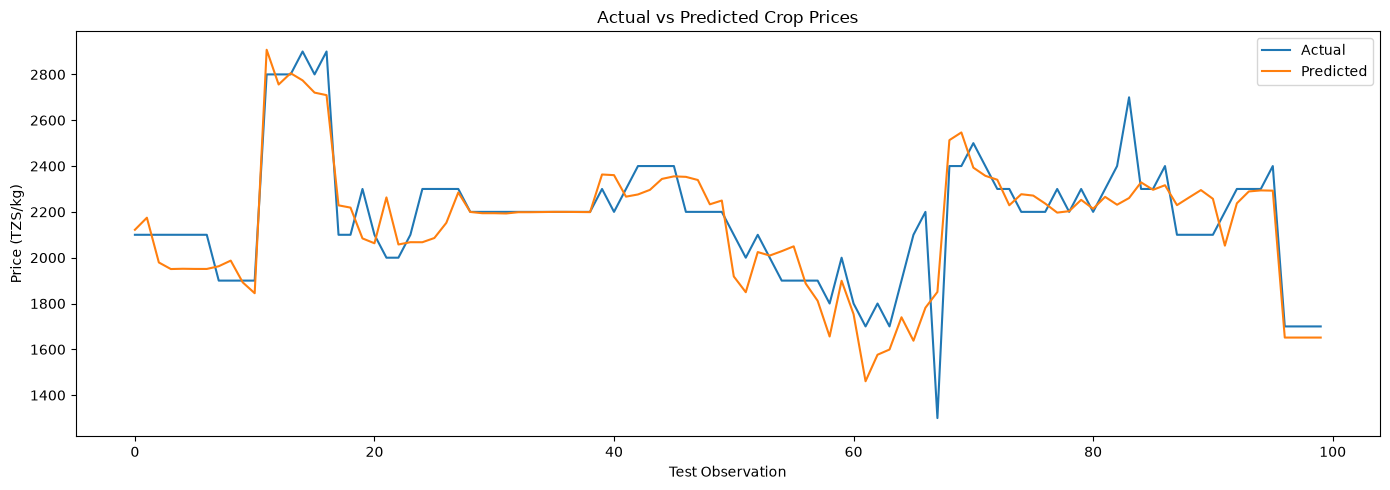

In [58]:
plot_data = results.head(100)

plt.figure(figsize=(14, 5))

plt.plot(
    plot_data["target_price"].values,
    label="Actual"
)

plt.plot(
    plot_data["predicted_price"].values,
    label="Predicted"
)

plt.title(
    "Actual vs Predicted Crop Prices"
)

plt.xlabel("Test Observation")
plt.ylabel("Price (TZS/kg)")
plt.legend()
plt.tight_layout()
plt.show()

25. save the trained model

In [59]:
MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

model_package = {
    "pipeline": pipeline,
    "features": features,
    "categorical_features":
        categorical_features,
    "numeric_features":
        numeric_features,
    "metrics": {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
        "mape": float(mape),
        "baseline_mae":
            float(baseline_mae),
        "baseline_rmse":
            float(baseline_rmse),
        "baseline_r2":
            float(baseline_r2),
        "baseline_mape":
            float(baseline_mape),
    },
}

joblib.dump(
    model_package,
    MODEL_PATH
)

print(
    "Model saved to:",
    MODEL_PATH.resolve()
)

Model saved to: /home/salmah/Documents/agri-market-ai/backend/ml/models/price_model.joblib


In [60]:
model_data = pd.read_csv(
    "../data/processed/model_dataset.csv"
)
model_data.head(20)

,crop,region,week_start,price,price_lag_1,price_lag_2,price_lag_3,price_lag_4,change_1w,change_2w,pct_change_1w,month,week_of_year,year,rolling_mean_4,rolling_std_4,target_price
0,beans,Arusha,2024-12-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,49,2024,NaN,NaN,2600.0
1,beans,Arusha,2024-12-09,2600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,50,2024,NaN,NaN,2700.0
2,beans,Arusha,2024-12-16,2700.0,2600.0,NaN,NaN,NaN,NaN,NaN,NaN,12,51,2024,NaN,NaN,2700.0
3,beans,Arusha,2024-12-23,2700.0,2700.0,2600.0,NaN,NaN,100.0,NaN,3.846154,12,52,2024,NaN,NaN,2700.0
4,beans,Arusha,2024-12-30,2700.0,2700.0,2700.0,2600.0,NaN,0.0,100.0,0.000000,12,1,2024,NaN,NaN,2700.0
5,beans,Arusha,2025-01-06,2700.0,2700.0,2700.0,2700.0,2600.0,0.0,0.0,0.000000,1,2,2025,2675.0,50.000000,2800.0
6,beans,Arusha,2025-01-13,2800.0,2700.0,2700.0,2700.0,2700.0,0.0,0.0,0.000000,1,3,2025,2700.0,0.000000,2700.0
7,beans,Arusha,2025-01-20,2700.0,2800.0,2700.0,2700.0,2700.0,100.0,0.0,3.703704,1,4,2025,2725.0,50.000000,2800.0
8,beans,Arusha,2025-01-27,2800.0,2700.0,2800.0,2700.0,2700.0,-100.0,100.0,-3.571429,1,5,2025,2725.0,50.000000,2700.0
9,beans,Arusha,2025-02-03,2700.0,2800.0,2700.0,2800.0,2700.0,100.0,-100.0,3.703704,2,6,2025,2750.0,57.735027,2700.0


In [61]:
print("Raw rows:", len(raw_data))
print("Cleaned rows:", len(cleaned_data))
print("Model rows:", len(model_data))

Raw rows: 11865
Cleaned rows: 8953
Model rows: 14924
